In [1]:
import yfinance as yf
import pandas as pd

In [2]:
# List of stock symbols for top 5 tech companies
tech_companies = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']

In [3]:
# Create an empty DataFrame to store all the data
all_data = pd.DataFrame()

In [4]:
# Loop through each stock symbol
for symbol in tech_companies:
    # Fetch the stock data for the year 2024
    stock = yf.Ticker(symbol)
    data = stock.history(start="2020-01-01", end="2024-12-31")
    
    # Add the company symbol as a column
    data['Company'] = symbol
    
    # Append this company's data to the main DataFrame
    all_data = all_data.append(data)

# Save the combined data to a CSV file
all_data.to_csv('Stock_data.csv')

print("Stock data for top 5 tech companies saved to CSV.")

/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)


Stock data for top 5 tech companies saved to CSV.


/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/225283762.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)


In [5]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6280 entries, 2020-01-02 00:00:00-05:00 to 2024-12-27 00:00:00-05:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          6280 non-null   float64
 1   High          6280 non-null   float64
 2   Low           6280 non-null   float64
 3   Close         6280 non-null   float64
 4   Volume        6280 non-null   int64  
 5   Dividends     6280 non-null   float64
 6   Stock Splits  6280 non-null   float64
 7   Company       6280 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 441.6+ KB


### 1. ARIMA Model: Stock Price Prediction

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import yfinance as yf


#### Load and preprocess the data:

                           Date       Open       High        Low      Close  \
3768  2020-01-02 00:00:00-05:00  93.750000  94.900497  93.207497  94.900497   
3769  2020-01-03 00:00:00-05:00  93.224998  94.309998  93.224998  93.748497   
3770  2020-01-06 00:00:00-05:00  93.000000  95.184502  93.000000  95.143997   
3771  2020-01-07 00:00:00-05:00  95.224998  95.694504  94.601997  95.343002   
3772  2020-01-08 00:00:00-05:00  94.902000  95.550003  94.321999  94.598503   

        Volume  Dividends  Stock Splits Company  
3768  80580000        0.0           0.0    AMZN  
3769  75288000        0.0           0.0    AMZN  
3770  81236000        0.0           0.0    AMZN  
3771  80898000        0.0           0.0    AMZN  
3772  70160000        0.0           0.0    AMZN  


/var/folders/bm/qyz3cng94_30bplqwctsvb8r0000gn/T/ipykernel_37121/548708846.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_data['Date'] = pd.to_datetime(amazon_data['Date'])


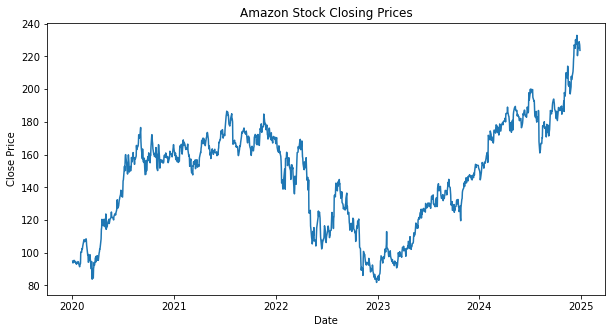

In [7]:
# Load the stock data
# Assuming your file is named 'Stock_data.csv'
stock_data = pd.read_csv('Stock_data.csv')


# Filter data for Apple (or any one company)
# Assuming the data has a column 'Company' that indicates the stock symbol
amazon_data = stock_data[stock_data['Company'] == 'AMZN']

# Check the first few rows of data
print(amazon_data.head())

# Convert the 'Date' column to datetime format and set it as the index
amazon_data['Date'] = pd.to_datetime(amazon_data['Date'])
amazon_data.set_index('Date', inplace=True)

# Keep only the 'Close' price, which is usually used for stock prediction
amazon_data_close = amazon_data[['Close']]

# Plot the data to visualize
plt.figure(figsize=(10, 5))
plt.plot(amazon_data_close)
plt.title('Amazon Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


#### Differencing the data for stationarity (required for ARIMA):

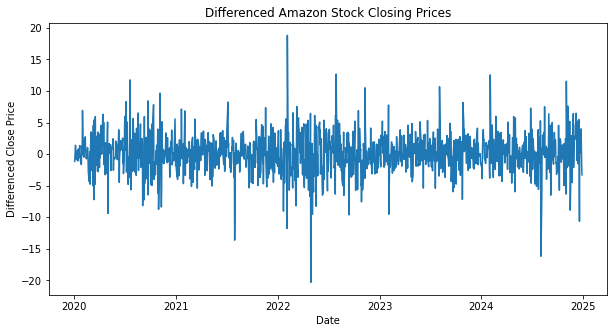

In [8]:
# Check if the data is stationary by differencing it
amazon_data_diff = amazon_data_close.diff().dropna()

# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(amazon_data_diff)
plt.title('Differenced Amazon Stock Closing Prices')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.show()


#### Train-test split:

In [9]:
# Split the data into train and test sets (80% train, 20% test)
train_size = int(len(amazon_data_close) * 0.8)
train, test = amazon_data_close[:train_size], amazon_data_close[train_size:]

# Check the shapes of the sets
print("Train set size:", train.shape)
print("Test set size:", test.shape)


Train set size: (1004, 1)
Test set size: (252, 1)


#### Build and train the ARIMA model:

In [10]:
# Build the ARIMA model
# The (p, d, q) parameters are chosen based on ACF and PACF plots or trial and error.
# You can try different combinations of (p, d, q) to get the best result.
model_arima = ARIMA(train, order=(5, 1, 0))  # Example (5, 1, 0), feel free to tune

# Fit the model
arima_result = model_arima.fit()

# Summary of the ARIMA model
print(arima_result.summary())


/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1004
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2556.369
Date:                Mon, 30 Dec 2024   AIC                           5124.737
Time:                        04:18:45   BIC                           5154.202
Sample:                             0   HQIC                          5135.934
                               - 1004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0233      0.028     -0.837      0.403      -0.078       0.031
ar.L2          0.0128      0.031      0.415      0.678      -0.048       0.073
ar.L3         -0.0417      0.027     -1.537      0.1

In [11]:
print(test.columns)

Index(['Close'], dtype='object')


#### Forecasting and evaluating the ARIMA model:

/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


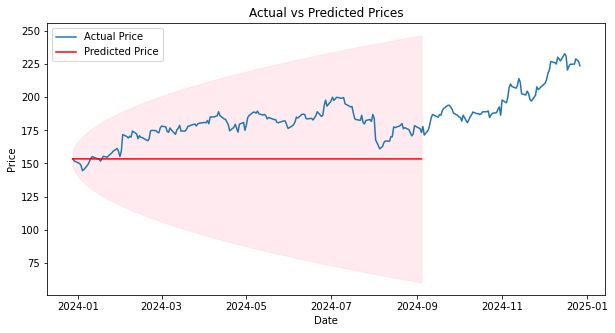

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Generate the forecast using the fitted ARIMA model
# Assume you want to forecast for the length of your test dataset
forecast_length = len(test)  # Length of the test dataset
forecast = arima_result.get_forecast(steps=forecast_length)
forecast_index = pd.date_range(start=test.index[0], periods=forecast_length, freq='D')  # Adjust frequency if necessary

# Get the predicted mean and confidence intervals
predicted_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Plot actual vs. predicted prices
plt.figure(figsize=(10, 5))
plt.plot(test.index, test['Close'], label='Actual Price')  # Replace 'Price' with the actual column name
plt.plot(forecast_index, predicted_mean, label='Predicted Price', color='red')
plt.fill_between(forecast_index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3)

plt.title('Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()



In [16]:
pip install --upgrade numpy


  Using cached numpy-2.0.2-cp39-cp39-macosx_10_9_x86_64.whl (21.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.0.2 which is incompatible.
scipy 1.7.3 requires numpy<1.23.0,>=1.16.5, but you have numpy 2.0.2 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 2.0.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip uninstall tensorflow


Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Would remove:
    /Users/anjalipatel/opt/anaconda3/bin/tensorboard
    /Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/tensorflow-2.16.2.dist-info/*
    /Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/tensorflow/*
Proceed (Y/n)? 

### 2. LSTM Model: Stock Price Prediction

In [15]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf

SystemError: initialization of _pywrap_checkpoint_reader raised unreported exception

#### Preprocess data for LSTM:

In [14]:
# Normalize the data using MinMaxScaler (LSTM requires scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(amazon_data_close)

# Prepare the data for LSTM
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time_step (window size)
time_step = 60

# Split the data into training and testing sets
train_size = int(len(scaled_data) * 0.8)
test_size = len(scaled_data) - train_size
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:len(scaled_data), :]

# Reshape into X=t, Y=t+1 for LSTM input
X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


#### Build and train the LSTM model:

In [15]:
# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dense(25))
model_lstm.add(Dense(1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train, Y_train, batch_size=48, epochs=20)


Epoch 1/20


/Users/anjalipatel/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0692
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0062
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0045
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0036
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0033
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0032
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0030
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0032
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0030
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0029
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0027
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0024
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0026
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0023
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0024
Epoch 16/20
19/

#### Predict and evaluate LSTM model:

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
LSTM RMSE: 177.49869375114804


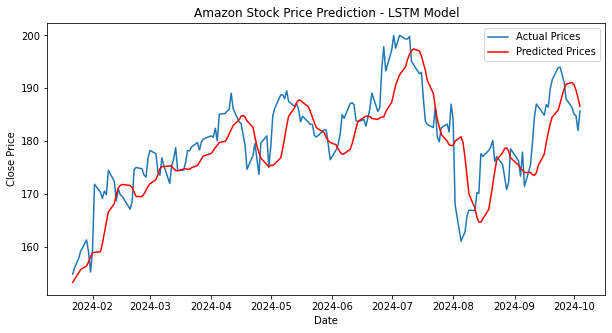

In [16]:
# Make predictions
train_predict = model_lstm.predict(X_train)
test_predict = model_lstm.predict(X_test)

# Inverse transform predictions to actual prices
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Calculate RMSE
rmse_lstm = np.sqrt(mean_squared_error(Y_test, test_predict))
print('LSTM RMSE:', rmse_lstm)

# Plot the predictions and actual prices
plt.figure(figsize=(10, 5))
plt.plot(amazon_data_close.index[-len(Y_test):], scaler.inverse_transform(scaled_data[-len(Y_test):]), label='Actual Prices')
plt.plot(amazon_data_close.index[-len(test_predict):], test_predict, label='Predicted Prices', color='red')
plt.title('Amazon Stock Price Prediction - LSTM Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


                           Actual Prices  Predicted Prices Signal
Date                                                             
2024-01-22 00:00:00-05:00     154.779999        153.212540   Sell
2024-01-23 00:00:00-05:00     156.020004        153.869751   Sell
2024-01-24 00:00:00-05:00     156.869995        154.435867   Sell
2024-01-25 00:00:00-05:00     157.750000        155.023605   Sell
2024-01-26 00:00:00-05:00     159.119995        155.647888   Sell
...                                  ...               ...    ...
2024-09-30 00:00:00-04:00     186.330002        191.088379    Buy
2024-10-01 00:00:00-04:00     185.130005        190.664459    Buy
2024-10-02 00:00:00-04:00     184.759995        189.621643    Buy
2024-10-03 00:00:00-04:00     181.960007        188.168991    Buy
2024-10-04 00:00:00-04:00     185.689697        186.584686    Buy

[179 rows x 3 columns]


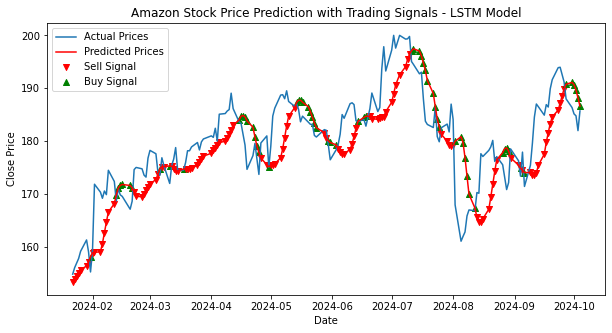

In [19]:
# Create a DataFrame for predicted prices
predicted_prices_df = pd.DataFrame(data=test_predict, index=amazon_data_close.index[-len(test_predict):], columns=['Predicted Prices'])

# Create a DataFrame for actual prices
actual_prices_df = pd.DataFrame(data=scaler.inverse_transform(scaled_data[-len(Y_test):]), index=amazon_data_close.index[-len(Y_test):], columns=['Actual Prices'])

# Combine both DataFrames
combined_df = actual_prices_df.join(predicted_prices_df)

# Generate trading signals
def generate_signals(df):
    signals = []
    for i in range(len(df)):
        if df['Predicted Prices'].iloc[i] > df['Actual Prices'].iloc[i]:
            signals.append('Buy')  # Buy signal
        elif df['Predicted Prices'].iloc[i] < df['Actual Prices'].iloc[i]:
            signals.append('Sell')  # Sell signal
        else:
            signals.append('Hold')  # Hold signal
    return signals

# Apply the function to generate signals
combined_df['Signal'] = generate_signals(combined_df)

# Display the trading signals
print(combined_df)

# Plotting actual vs predicted prices with signals
plt.figure(figsize=(10, 5))
plt.plot(combined_df.index, combined_df['Actual Prices'], label='Actual Prices')
plt.plot(combined_df.index, combined_df['Predicted Prices'], label='Predicted Prices', color='red')

# Mark Buy and Sell signals
for i in range(len(combined_df)):
    if combined_df['Signal'].iloc[i] == 'Buy':
        plt.scatter(combined_df.index[i], combined_df['Predicted Prices'].iloc[i], marker='^', color='green', label='Buy Signal' if 'Buy Signal' not in plt.gca().get_legend_handles_labels()[1] else "")
    elif combined_df['Signal'].iloc[i] == 'Sell':
        plt.scatter(combined_df.index[i], combined_df['Predicted Prices'].iloc[i], marker='v', color='red', label='Sell Signal' if 'Sell Signal' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title('Amazon Stock Price Prediction with Trading Signals - LSTM Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [20]:
# Save the model
model_lstm.save('amazon_stock_lstm_model.h5')  # Save as HDF5 file

# To load the model later:
from keras.models import load_model
loaded_model = load_model('amazon_stock_lstm_model.h5')